In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.gridspec import GridSpec
import matplotlib

import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger

from schmitt_tdvp_blur import TDVPSchmittBlur
from schmitt_tdvp import TDVPSchmitt

import argparse
import numpy as np

from gaussian_state import GaussianState
from tfim_exact_majorana import run_ed


/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Use driver.run(..., timeit=True) to know where your dominant cost is.

In [3]:
import flax.linen as nn
import jax.numpy as jnp
from netket.hilbert import DiscreteHilbert

class AlphaBetaState(nn.Module):
    r"""Tiny Flax model with two scalar trainable parameters (alpha, beta).
    Intended to demonstrate initialization from python floats.
    """
    hilbert: DiscreteHilbert
    alpha0: complex = 0.0
    beta0: complex = 0.0

    @nn.compact
    def __call__(self, x_in):
        """Return a batch of log-psi values."""
        assert self.hilbert.size==1., "Only works for single qubit state"
        alpha = self.param("alpha", nn.initializers.constant(self.alpha0, dtype=complex), ())
        beta = self.param("beta", nn.initializers.constant(self.beta0, dtype=complex), ())
        out = jnp.where(x_in==1, alpha, beta)
        return jnp.log(out).squeeze()
    
hilbert = nk.hilbert.Spin(s=1 / 2, N=1)

def get_vstate(n_samples):
    # Small system because the dense S-matrix scales like O(N_params^2).
    # Increase L/alpha only if you really need the full dense matrix.
    seed = 100

    # Hilbert space: L spin-1/2 sites
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains = n_samples)

    # Model initialized from two python floats -> trainable params start at these values
    model = AlphaBetaState(
        hilbert=hilbert,
        alpha0=1.0,
        beta0=1.0,
    )

    # Variational Monte Carlo state
    vstate = nk.vqs.MCState(
        sampler=sampler,
        model=model,
        n_samples=n_samples,
        seed=seed
    )
    x = vstate.sample(n_samples=n_samples)
    psi = vstate.to_array()
    print(psi)
    return vstate

In [4]:


fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values")
)

hamiltonian = nk.operator.PauliStringsJax(hilbert, "Y", 1.)
sigma_z = nk.operator.PauliStringsJax(hilbert, "Z", 1.)

def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_z)
    return True

In [ ]:
from schmitt_tdvp_blur import TDVPSchmittBlur
from schmitt_tdvp import TDVPSchmitt

def run(q, n_samples_tvmc):

    T = 2.
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"blur_{n_samples_tvmc}_q_{q:1.2f}"
    # Make sure we always start with the same state in notebook

    vstate = get_vstate(n_samples_tvmc)
    save_path = f"./data/SIGMA_Y/{exp_name}/"
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    logger = Logger(path=save_path, fields=fields_to_track)
    restored = logger.restore()
    if restored and logger.done:
        return
    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    callbacks.append(get_parameter_save_callback(save_times, logger))
    # callbacks.append(get_acceptance_rate_callback())
    if q==0:
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    else:
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
        
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    # thermalize
    for i in range(100):
        vstate.sample()
    print(vstate.expect(sigma_z))
    if jnp.isclose(q, 0):
        driver = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        driver = TDVPSchmittBlur(
            hamiltonian,
            vstate,
            integrator,
            t0=0,
            q=q,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            diagonal_mels=False,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(done=True)
run(0.0, 2**14)
run(0.8, 2**14)

[0.70710678+0.j 0.70710678+0.j]
[0.70710678+0.j 0.70710678+0.j]


In [7]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = hamiltonian.to_sparse()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)
vstate = get_vstate(2**10)
# Get initial state from vstate
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert netket operator to matrix
sigma_z_matrix = sigma_z.to_dense()
# Convert to QuTiP
Z_total_qutip = qt.Qobj(sigma_z_matrix)

# Time evolution parameters
T = 2.
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    mag = qt.expect(Z_total_qutip, psi_t)
    magnetizations_exact.append(mag)

[0.70710678+0.j 0.70710678+0.j]


Restored: True
Restored: True


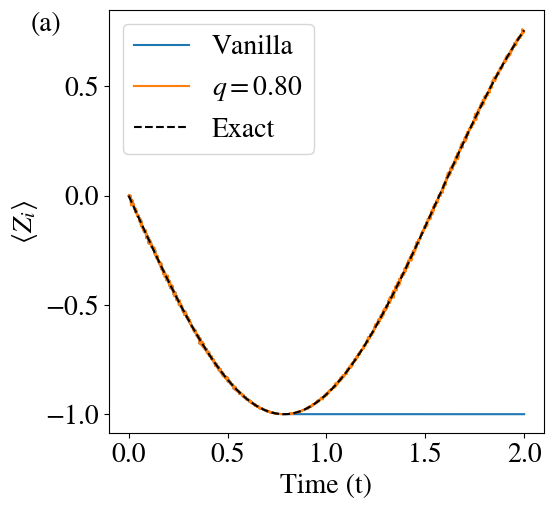

In [8]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
n_samples_tvmc = 2**14
fig = plt.figure(figsize=(5.8, 5.5))
gs = GridSpec(1, 1, figure=fig, wspace=0.45, hspace=0.33)
ax_z = fig.add_subplot(gs[0])

# Add whitespace to the left of the plot
fig.subplots_adjust(left=0.15)

for q in [0.0, 0.8]:
    exp_name = f"blur_{n_samples_tvmc}_q_{q:1.2f}"
    save_path = f"./data/SIGMA_Y/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    ax_z.plot(
        logger.data["t"]["values"],
        np.array(logger.data["sigma_z"]["Mean"]).real,
        label="Vanilla" if q == 0 else f"$q=${q:1.2f}",
    )
ax_z.plot(
    times_exact, magnetizations_exact, label="Exact", linestyle="--", color="black"
)
loc_x = -0.18
loc_y = 0.95
ax_z.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=20)
ax_z.set_xlabel("Time (t)", fontsize=20)
ax_z.set_ylabel(r"$\langle Z_i \rangle$", fontsize=20)
ax_z.legend(fontsize=20)
ax_z.tick_params(labelsize=20)
fig.savefig("Fig4a.pdf",bbox_inches="tight", pad_inches=0.01)

In [9]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn

L = 2
N = L**2
J0 = 1.0
hilbert = nk.hilbert.Spin(s=1 / 2, N=N, total_sz=0)

graph = nk.graph.Grid((L, L), pbc=False)
hamiltonian = nk.operator.Heisenberg(hilbert, graph, J=1 / 4)


def get_vstate(n_samples):
    sampler = nk.sampler.MetropolisExchange(hilbert, graph=graph, n_chains=n_samples)
    model = nk.models.RBM(
        alpha=1/N,
        param_dtype=complex,
        use_visible_bias=True,
        hidden_bias_init=nn.initializers.normal(1e-4),
        visible_bias_init=nn.initializers.normal(1e-4),
        kernel_init=nn.initializers.normal(1e-4),
    )
    return nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )


def get_vstate_parameters(n_samples):
    vstate = get_vstate(n_samples)

    # Thermalize
    for i in range(0):
        vstate.sample(n_samples=n_samples)
    e0 = nk.exact.lanczos_ed(hamiltonian)

    gs = nk.driver.VMC_SR(
        hamiltonian,
        optimizer=nk.optimizer.Sgd(0.01),
        variational_state=vstate,
        diag_shift=1e-4,
    )
    gs.run(1000, callback=lambda s, l, d: d._loss_stats.mean > e0 + 1e-3)
    return vstate.parameters


vstate = get_vstate(2**10)
parameters = get_vstate_parameters(2**10)
vstate.parameters = parameters.copy()
e0 = nk.exact.lanczos_ed(hamiltonian)
estimated_e = vstate.expect(hamiltonian)
print(f"GS energy {e0}")
print(f"variational energy {estimated_e}")

Automatic SR implementation choice:  QGT


  2%|▏         | 24/1000 [00:00<00:15, 64.42it/s, Energy=-2.0013+0.0058j ± 0.0068 [σ²=4.7e-02]]


GS energy [-2.]
variational energy -1.9796-0.0013j ± 0.0069 [σ²=4.9e-02]


In [10]:
graph = nk.graph.Chain(N, pbc=True)

deltaJ = -2
vertical_bonds = []
for x in range(L):
    for y in range(L - 1):
        i = x * L + y
        j = x * L + (y + 1)
        vertical_bonds.append((i, j))
vertical_bonds_graph = nk.graph.Graph(edges=vertical_bonds)
vertical_heisenberg = nk.operator.Heisenberg(hilbert,  vertical_bonds_graph, J=deltaJ/4)
quench_hamiltonian = hamiltonian + vertical_heisenberg
single_edge = nk.graph.Graph(edges=(vertical_bonds[0],))
s_correlator = nk.operator.Heisenberg(hilbert, single_edge, J=1./4)

fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("s_corr", "Mean"),
    ("s_corr", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_corr(step, log, driver):
    log['s_corr'] = driver.state.expect(s_correlator)
    return True

In [11]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = quench_hamiltonian.to_dense()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)

# Get initial state from vstate
vstate = get_vstate(2**10)
vstate.parameters = parameters.copy()
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert to QuTiP
Scorr_qutip = qt.Qobj(s_correlator.to_dense() )

# Time evolution parameters
T = 6
times_exact_heisenberg = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact_heisenberg = []
for t in times_exact_heisenberg:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    corr = qt.expect(Scorr_qutip, psi_t)
    magnetizations_exact_heisenberg.append(corr)

In [14]:
from schmitt_tdvp_blur import TDVPSchmittBlur
from schmitt_tdvp import TDVPSchmitt


def fit_bridge(q, n_samples_tvmc):
    T = 1.5 * 4
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"blur_{n_samples_tvmc}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/HEISENBERG_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    vstate = get_vstate(n_samples_tvmc)
    vstate.parameters = parameters.copy()
    for i in range(1000):
        vstate.sample()
    callbacks = []
    callbacks.append(measure_corr)
    if q == 0:
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    else:
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    # integrator = RK45(1e-3, adaptive=False, rtol=1e-6, dt_limits=(1e-5, 1e-2))
    integrator = Heun(1e-3)
    tvmc_kwargs = {}
    if q == 0:
        driver = TDVPSchmitt(
            quench_hamiltonian,
            vstate,
            integrator,
            t0=0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        driver = TDVPSchmittBlur(
            quench_hamiltonian,
            vstate,
            integrator,
            t0=0,
            q=q,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [15]:
fit_bridge(0.0, 2**14)
fit_bridge(0.3, 2**14)

Data exists, skipping...
Data exists, skipping...


Restored: True
Restored: True


/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_3425699/3568852034.py:33: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z.plot(times_exact_heisenberg/4, np.real(magnetizations_exact_heisenberg), 'k-', linewidth=2, label='ED', linestyle='dashed')


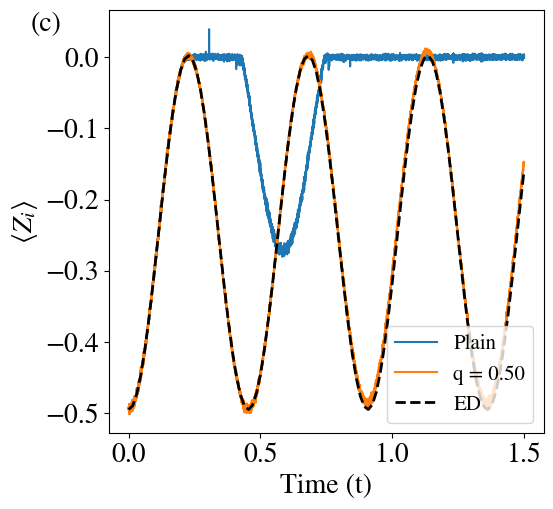

In [16]:
import matplotlib
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(5.8, 5.5))
fig.subplots_adjust(left=0.15)

gs = GridSpec(1, 1, figure=fig, wspace=0.45, hspace=0.33)
ax_z = fig.add_subplot(gs[0])
q=0
n_samples=2**14
exp_name = f"blur_{n_samples}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}"
save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
ax_z.plot(np.array(logger.data["t"]["values"])/4, logger.data["s_corr"]["Mean"], label = f"Plain", zorder=-1)

q=0.3
exp_name = f"blur_{n_samples}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}"
save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
ax_z.plot(np.array(logger.data["t"]["values"])/4, logger.data["s_corr"]["Mean"], label = f"q = {0.5:1.2f}", zorder=-1)

ax_z.set_xlabel("Time (t)", fontsize=20)
ax_z.set_ylabel(r"$\langle Z_i \rangle$", fontsize=20)
ax_z.tick_params(labelsize=20)
loc_x = -0.18
loc_y = 0.95
ax_z.annotate("(c)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=20)

ax_z.plot(times_exact_heisenberg/4, np.real(magnetizations_exact_heisenberg), 'k-', linewidth=2, label='ED', linestyle='dashed')
ax_z.legend(loc="lower right", fontsize=15)
fig.savefig("Fig4c.pdf",bbox_inches="tight", pad_inches=0.01)


# Combined figures

No data found for `s_corr` when restoring logger.
Restored: True
No data found for `s_corr` when restoring logger.
Restored: True
Restored: True
Restored: True


/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_3425699/431868871.py:80: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z_heisenberg.plot(


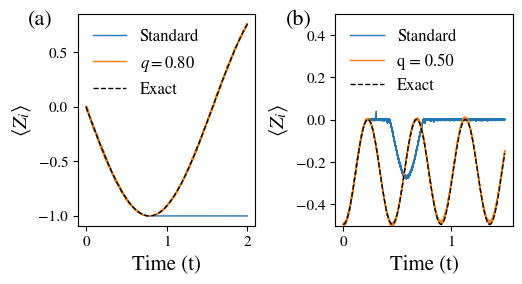

In [17]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
n_samples_tvmc = 2**14
fig = plt.figure(figsize=(5.8, 5.5 / 2))
gs = GridSpec(1, 2, figure=fig, wspace=0.45, hspace=0.33)
ax_z = fig.add_subplot(gs[0, 0])
ax_z_heisenberg = fig.add_subplot(gs[0, 1])

# Add whitespace to the left of the plot
fig.subplots_adjust(left=0.15)

for q in [0.0, 0.8]:
    exp_name = f"blur_{n_samples_tvmc}_q_{q:1.2f}"
    save_path = f"./data/SIGMA_Y/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    ax_z.plot(
        logger.data["t"]["values"],
        np.array(logger.data["sigma_z"]["Mean"]).real,
        label="Standard" if q == 0 else f"$q=${q:1.2f}",
        lw=1,
    )
ax_z.plot(
    times_exact,
    magnetizations_exact,
    label="Exact",
    linestyle="--",
    color="black",
    lw=1,
)
loc_x = -0.18
loc_y = 0.95
ax_z.set_xlabel("Time (t)", fontsize=15)
ax_z.set_ylabel(r"$\langle Z_i \rangle$", fontsize=15)
ax_z.legend(
    frameon=False,
    fontsize=12,
)
ax_z.tick_params(labelsize=11)

q = 0
n_samples = 2**14
exp_name = f"blur_{n_samples}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}"
save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
ax_z_heisenberg.plot(
    np.array(logger.data["t"]["values"]) / 4,
    logger.data["s_corr"]["Mean"],
    label=f"Standard",
    zorder=-1,
    lw=1,
)

q = 0.3
exp_name = f"blur_{n_samples}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}"
save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
ax_z_heisenberg.plot(
    np.array(logger.data["t"]["values"]) / 4,
    logger.data["s_corr"]["Mean"],
    label=f"q = {0.5:1.2f}",
    zorder=-1,
    lw=1,
)

ax_z_heisenberg.set_xlabel("Time (t)", fontsize=15)
ax_z_heisenberg.set_ylabel(r"$\langle Z_i \rangle$", fontsize=15)
ax_z_heisenberg.tick_params(labelsize=11)
ax_z_heisenberg.set_ylim([-0.5, 0.5])
loc_x = -0.28
loc_y = 0.95
ax_z.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_z_heisenberg.annotate(
    "(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16
)

ax_z_heisenberg.plot(
    times_exact_heisenberg / 4,
    np.real(magnetizations_exact_heisenberg),
    "k-",
    linewidth=1,
    label="Exact",
    linestyle="dashed",
)
ax_z_heisenberg.legend(loc="upper left", frameon=False, fontsize=12)

fig.savefig("Fig4.pdf", bbox_inches="tight", pad_inches=0.01)